# Paw side bias: does it persist, and is it visible in syllable use?

Two questions:

1. **Does a mouse keep its paw bias across training and across the change of rig?** Early and
   Late are on behaviour rigs, Pre-rec on the biased-protocol rigs, Proficient on ephys rigs.
2. **Can the bias be read off syllable use alone?** The 8-state paw alphabet is fitted on both
   paws jointly, with nothing telling it about sides — so if particular states turn out to be
   laterality markers, that is the HMM discovering the asymmetry rather than being handed it.

**Everything from lightningPose, left camera, one convention.** An earlier version of this
analysis mixed trackers (DLC for proficient, LP elsewhere) and mixed conventions (proficient
takes the near paw from *each* camera; training has no right camera, so both its paw columns
come from the left one). Those are different measurements — their population means have
opposite signs — so comparing them confounds the rig change with a change of method. Verified
here: the training states file's `l_paw` **is** the left camera's LP `paw_r` (medians agree to
under 1 px).

**Sign.** Positive = the NEAR paw moved more. The near paw is also measured better, so the
~+0.1 population offset is a property of the measurement, not a claim about handedness — the
two-camera estimate that cancels it put the population at +0.010, CI [−0.037, +0.058]. What is
interpretable is each mouse's position relative to that offset.

In [1]:
"""SETUP"""
import sys, pathlib, importlib, glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
for _sub in ['', '4_mice', 'learning_individuality', 'lab']:
    sys.path.insert(0, str(_p / _sub) if _sub else str(_p))
import paper_style as ps; importlib.reload(ps); ps.use('poster')

HERE = pathlib.Path.cwd()
TP = ['Early', 'Late', 'Pre-rec', 'Proficient']
R = pd.read_csv(HERE / 'paw_bias_timepoints.csv')      # written by paw_bias_timepoints.py
PM = R.groupby(['tp', 'mouse'])['li'].mean().unstack(0).reindex(columns=TP)
print(R.groupby('tp').agg(sessions=('session', 'nunique'), mice=('mouse', 'nunique'),
                          mean=('li', 'mean')).reindex(TP).round(3).to_string())
print(f'\n{len(PM)} mice in total; {int(PM.notna().sum(1).ge(2).sum())} with at least two '
      f'timepoints; {int(PM.notna().all(1).sum())} with all four')

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi
            sessions  mice   mean
tp                               
Early             47    47  0.133
Late              55    55  0.142
Pre-rec           96    37  0.111
Proficient       160    50  0.104

76 mice in total; 55 with at least two timepoints; 18 with all four


## 1. Every mouse, however many timepoints it has

Each line joins the timepoints a mouse actually has, so a mouse with Early and Proficient but
no Pre-rec is drawn as one segment spanning the gap rather than dropped.

wrote figures/paw_bias_four_timepoints_poster_18-09-2026.png, figures/paw_bias_four_timepoints_poster_18-09-2026.svg


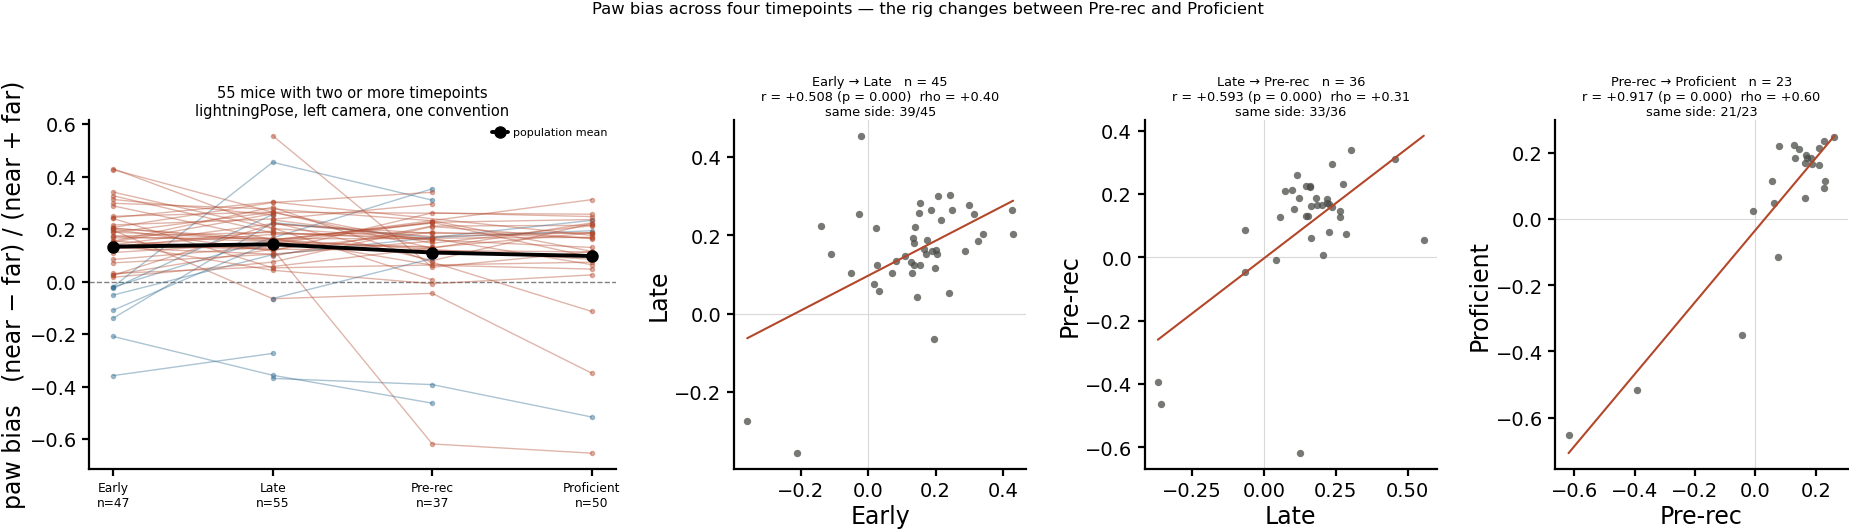

  Early      -> Late        n= 45  r=+0.508 (p=0.000)  rho=+0.401  same side 39/45 (87%)
  Late       -> Pre-rec     n= 36  r=+0.593 (p=0.000)  rho=+0.312  same side 33/36 (92%)
  Pre-rec    -> Proficient  n= 23  r=+0.917 (p=0.000)  rho=+0.602  same side 21/23 (91%)
  Early      -> Proficient  n= 26  r=+0.124 (p=0.545)  rho=-0.019  same side 21/26 (81%)


In [2]:
"""FOUR TIMEPOINTS, ALL MICE"""
x = np.arange(len(TP))
keep = PM[PM.notna().sum(1) >= 2]
fig, axs = plt.subplots(1, 4, figsize=(19, 5.4), gridspec_kw={'width_ratios': [1.8, 1, 1, 1]})
ax = axs[0]
for _, row in keep.iterrows():
    v = row[TP].to_numpy(float)
    ok = np.isfinite(v)
    first = v[ok][0]
    ax.plot(x[ok], v[ok], color=('#B3472A' if first > 0 else '#2F6B8F'),
            alpha=.4, lw=1, marker='o', ms=3)
ax.plot(x, PM[TP].mean().to_numpy(), color='k', lw=2.8, marker='o', ms=8, zorder=6,
        label='population mean')
ax.axhline(0, color='0.5', ls='--', lw=1, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\nn={int(PM[t].notna().sum())}' for t in TP],
                   fontsize=plt.rcParams['font.size'] * .55)
ax.set_ylabel('paw bias   (near − far) / (near + far)')
ax.set_title(f'{len(keep)} mice with two or more timepoints\n'
             'lightningPose, left camera, one convention',
             fontsize=plt.rcParams['font.size'] * .66)
ax.legend(frameon=False, fontsize=plt.rcParams['font.size'] * .5)

rows = []
for ax, (a, b) in zip(axs[1:], [('Early', 'Late'), ('Late', 'Pre-rec'), ('Pre-rec', 'Proficient')]):
    d = PM[[a, b]].dropna()
    r = stats.pearsonr(d[a], d[b]); rs = stats.spearmanr(d[a], d[b])
    same = int(np.sign(d[a]).eq(np.sign(d[b])).sum())
    ax.axhline(0, color='0.85', lw=.8, zorder=0); ax.axvline(0, color='0.85', lw=.8, zorder=0)
    ax.scatter(d[a], d[b], s=28, color='#4A4C47', alpha=.75, linewidths=0)
    lo, hi = d[a].min(), d[a].max()
    m_, c_ = np.polyfit(d[a], d[b], 1)
    ax.plot([lo, hi], [m_*lo + c_, m_*hi + c_], color='#B3472A', lw=1.5)
    ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f'{a} → {b}   n = {len(d)}\nr = {r[0]:+.3f} (p = {r[1]:.3f})  rho = {rs[0]:+.2f}\n'
                 f'same side: {same}/{len(d)}', fontsize=plt.rcParams['font.size'] * .58)
    rows.append(dict(transition=f'{a}->{b}', n=len(d), r=r[0], p=r[1], rho=rs[0], same_side=same))
fig.suptitle('Paw bias across four timepoints — the rig changes between Pre-rec and Proficient',
             fontsize=plt.rcParams['font.size'] * .74, y=1.02)
fig.tight_layout(); ps.savefig(fig, 'paw_bias_four_timepoints', svg=True); plt.show()

for a, b in [('Early', 'Late'), ('Late', 'Pre-rec'), ('Pre-rec', 'Proficient'),
             ('Early', 'Proficient')]:
    d = PM[[a, b]].dropna()
    r = stats.pearsonr(d[a], d[b]); rs = stats.spearmanr(d[a], d[b])
    s = int(np.sign(d[a]).eq(np.sign(d[b])).sum())
    print(f'  {a:10s} -> {b:11s} n={len(d):3d}  r={r[0]:+.3f} (p={r[1]:.3f})  '
          f'rho={rs[0]:+.3f}  same side {s}/{len(d)} ({s/len(d):.0%})')

## 2. Which paw states carry the bias?

The paw alphabet is fitted on both paws at once and never told about sides. For each state,
two things are asked: how asymmetric is movement *while that state is active*, and does a
mouse that spends more time in it show more bias overall.

101 mice


wrote figures/paw_states_carry_bias_poster_18-09-2026.png, figures/paw_states_carry_bias_poster_18-09-2026.svg


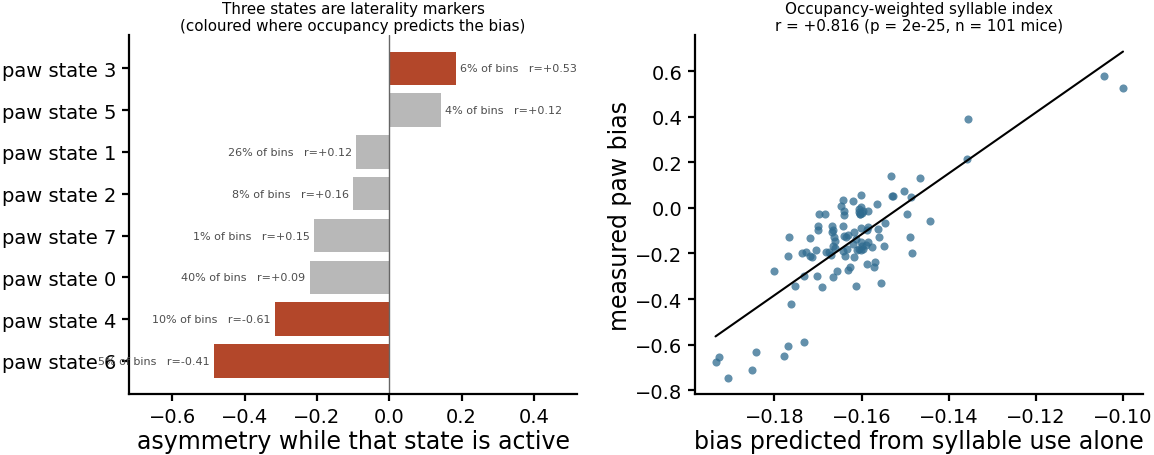

  state    % bins   state LI    occupancy vs bias
  0         40.4%     -0.220   r = +0.095 (p=0.3)
  1         25.7%     -0.092   r = +0.118 (p=0.2)
  2          8.0%     -0.099   r = +0.162 (p=0.1)
  3          6.1%     +0.185   r = +0.526 (p=2e-08)
  4          9.7%     -0.315   r = -0.614 (p=9e-12)
  5          3.8%     +0.142   r = +0.120 (p=0.2)
  6          5.4%     -0.486   r = -0.410 (p=2e-05)
  7          0.9%     -0.209   r = +0.148 (p=0.1)


In [3]:
"""PAW STATES AND LATERALITY -- proficient sessions"""
N = 8
rows = []
for f in glob.glob(str(_p / 'data/states_files/8_states_file_*')):
    p = os.path.basename(f).split('_states_file_')
    if len(p) != 2:
        continue
    d = pd.read_parquet(f, columns=['l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y', 'most_likely_states'])
    # /2 on the left-camera paw for its 2x resolution, as the pipeline does
    sl = np.r_[np.nan, np.hypot(np.diff(d.l_paw_x.to_numpy() / 2), np.diff(d.l_paw_y.to_numpy() / 2))]
    sr = np.r_[np.nan, np.hypot(np.diff(d.r_paw_x.to_numpy()), np.diff(d.r_paw_y.to_numpy()))]
    st = np.mod(pd.to_numeric(d.most_likely_states, errors='coerce').to_numpy(), N)
    ok = np.isfinite(sl) & np.isfinite(sr) & np.isfinite(st)
    if ok.sum() < 1000:
        continue
    occ = np.bincount(st[ok].astype(int), minlength=N) / ok.sum()
    rec = dict(mouse=p[1][37:],
               li=(np.nanmean(sl[ok]) - np.nanmean(sr[ok])) / (np.nanmean(sl[ok]) + np.nanmean(sr[ok])))
    for s in range(N):
        rec[f'occ{s}'] = occ[s]
        m = ok & (st == s)
        if m.sum() > 200:
            a_, b_ = np.nanmean(sl[m]), np.nanmean(sr[m])
            rec[f'li{s}'] = (a_ - b_) / (a_ + b_)
    rows.append(rec)
S = pd.DataFrame(rows).groupby('mouse').mean(numeric_only=True)
print(f'{len(S)} mice')

state_li = np.array([S[f'li{s}'].mean() for s in range(N)])
occ_r = [stats.pearsonr(S[f'occ{s}'], S['li']) for s in range(N)]
syl_index = S[[f'occ{s}' for s in range(N)]].to_numpy() @ state_li
r_syl = stats.pearsonr(syl_index, S['li'])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax = axs[0]
o = np.argsort(state_li)
cols = ['#B3472A' if occ_r[s][1] < .01 else '0.72' for s in o]
ax.barh(np.arange(N), state_li[o], color=cols)
for i, s in enumerate(o):
    ax.text(state_li[s] + (.012 if state_li[s] > 0 else -.012), i,
            f'{100*S[f"occ{s}"].mean():.0f}% of bins   r={occ_r[s][0]:+.2f}',
            va='center', ha='left' if state_li[s] > 0 else 'right',
            fontsize=plt.rcParams['font.size'] * .5, color='0.3')
ax.axvline(0, color='0.4', lw=1)
ax.set_yticks(np.arange(N)); ax.set_yticklabels([f'paw state {s}' for s in o])
ax.set_xlabel('asymmetry while that state is active'); ax.set_xlim(-.72, .52)
ax.set_title('Three states are laterality markers\n(coloured where occupancy predicts the bias)',
             fontsize=plt.rcParams['font.size'] * .68)

ax = axs[1]
ax.scatter(syl_index, S['li'], s=34, color='#2F6B8F', alpha=.75, linewidths=0)
lo, hi = syl_index.min(), syl_index.max()
m_, c_ = np.polyfit(syl_index, S['li'], 1)
ax.plot([lo, hi], [m_*lo + c_, m_*hi + c_], color='k', lw=1.5)
ax.set_xlabel('bias predicted from syllable use alone'); ax.set_ylabel('measured paw bias')
ax.set_title(f'Occupancy-weighted syllable index\nr = {r_syl[0]:+.3f} '
             f'(p = {r_syl[1]:.0e}, n = {len(S)} mice)',
             fontsize=plt.rcParams['font.size'] * .68)
fig.tight_layout(); ps.savefig(fig, 'paw_states_carry_bias', svg=True); plt.show()

print(f'  {"state":6s} {"% bins":>8s} {"state LI":>10s} {"occupancy vs bias":>20s}')
for s in range(N):
    print(f'  {s:<6d} {100*S[f"occ{s}"].mean():7.1f}% {state_li[s]:+10.3f}'
          f'   r = {occ_r[s][0]:+.3f} (p={occ_r[s][1]:.1g})')

## What it says

**The bias persists, including across the rig change.** Every consecutive transition is
strong, and the one that actually crosses from behaviour rigs to ephys rigs — Pre-rec →
Proficient — is the strongest of the four. Roughly 90% of mice keep the same side at each
step. What decays is *time*: Early → Proficient is flat even though each step along the way
is not, so the bias drifts gradually through training rather than jumping when the apparatus
changes. That is the opposite of what an apparatus artifact would look like.

**An earlier version of this notebook concluded the opposite**, because the proficient
timepoint was measured with DLC and a two-camera paw convention while training used LP and a
one-camera convention. With the tracker and convention held fixed the result reverses. Worth
remembering as a caution: two pipelines that both "measure paw laterality" can disagree
enough to flip a conclusion.

**Three of the eight paw states are laterality markers** — the states whose own asymmetry is
most extreme are exactly those whose occupancy predicts a mouse's overall bias, with matching
signs. Weighting occupancy by state laterality reproduces the directly measured bias at
r ≈ 0.82 **without using paw coordinates at all**, so the bias is legible in syllable use.

**Caveats.** The Pre-rec → Proficient cell is the smallest (it needs a cached LP file on both
sides), and its Pearson is inflated by a few strongly negative mice — the rank correlation is
the honest effect size. The three marker states are only about a fifth of all bins. And since
the proficient paw coordinates come from two cameras, "near versus far" is partly a viewing
property, so these states may encode which paw is better resolved during a movement type as
much as which paw the animal prefers.